# 01 · Regresión lineal

## Objetivo

En este notebook vamos a construir y entender un modelo de **regresión lineal** usando un ejemplo sintético inspirado en ATM.

La idea será estimar el **tiempo total de coordinación operativa** en una ventana de 15 minutos a partir del **número de vuelos** que atraviesan un sector.

El objetivo no es afirmar que la relación real sea lineal —en sistemas ATM reales probablemente intervienen muchas más variables y no linealidades—, sino disponer de un problema sencillo para comprender:

- qué es una variable de entrada (`X`) y una variable objetivo (`y`);
- qué representan la pendiente y el intercepto;
- cómo se calcula el error;
- qué es la función de pérdida MSE;
- cómo aprende un modelo;
- cómo separar entrenamiento y test;
- cómo evaluar el modelo;
- qué son los residuos;
- y cómo se relaciona todo esto con `scikit-learn`.

> Los datos de este notebook son completamente sintéticos.


## 1. Importaciones


In [2]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


Python: 3.14.8
NumPy: 2.5.3
Pandas: 3.0.6


## 2. Crear un pequeño conjunto de datos ATM sintético

Supongamos que observamos ventanas de 15 minutos.

Para cada ventana disponemos de:

- `flights_15min`: número de vuelos que atraviesan el sector;
- `coordination_minutes`: minutos totales dedicados a coordinación operativa.

Generaremos los datos a partir de una relación aproximadamente lineal:

\[
y = b + wx + \epsilon
\]

donde:

- \(x\) es el número de vuelos;
- \(w\) es la pendiente;
- \(b\) es el intercepto;
- \(\epsilon\) representa ruido aleatorio.


In [3]:
rng = np.random.default_rng(42)

n_samples = 120

flights_15min = rng.integers(4, 31, size=n_samples)

true_intercept = 2.5
true_slope = 0.85
noise = rng.normal(loc=0.0, scale=2.2, size=n_samples)

coordination_minutes = (
    true_intercept
    + true_slope * flights_15min
    + noise
)

df = pd.DataFrame({
    "flights_15min": flights_15min,
    "coordination_minutes": coordination_minutes
})

df.head()


,flights_15min,coordination_minutes
0,6,5.695172
1,24,25.030212
2,21,16.647687
3,15,14.513253
4,15,15.608057


## 3. Explorar los datos

Antes de entrenar un modelo conviene mirar los datos.

En problemas reales esta fase sería mucho más importante: valores ausentes, unidades, distribuciones, outliers, calidad de las fuentes, etc.


In [4]:
df.describe()


,flights_15min,coordination_minutes
count,120.000000,120.000000
mean,17.583333,17.185507
std,7.421956,6.701627
min,4.000000,3.568673
25%,11.000000,11.453624
50%,17.500000,17.236402
75%,24.000000,22.601923
max,30.000000,31.542808


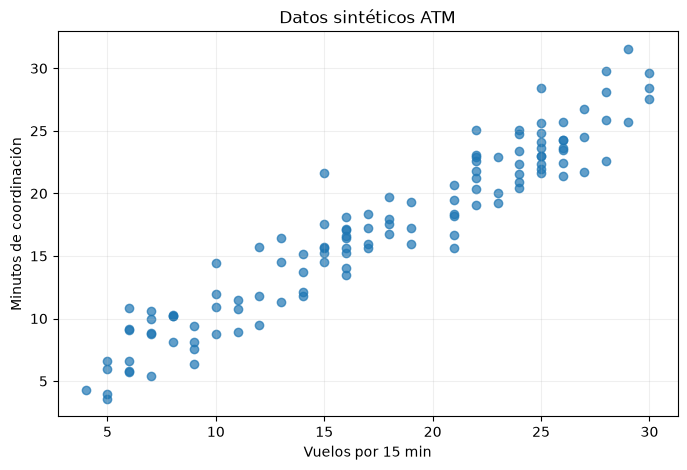

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df["flights_15min"], df["coordination_minutes"], alpha=0.7)
plt.xlabel("Vuelos por 15 min")
plt.ylabel("Minutos de coordinación")
plt.title("Datos sintéticos ATM")
plt.grid(alpha=0.2)
plt.show()


A simple vista parece existir una relación aproximadamente lineal: al aumentar el número de vuelos, aumenta también el tiempo de coordinación.

La regresión lineal intentará encontrar la recta:

\[
\hat{y} = b + wx
\]

que mejor se ajuste a los datos.


## 4. Separar `X` e `y`

En aprendizaje supervisado distinguimos:

- **features / variables de entrada**: `X`;
- **target / variable objetivo**: `y`.


In [6]:
X = df[["flights_15min"]]
y = df["coordination_minutes"]

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


Forma de X: (120, 1)
Forma de y: (120,)


Observa que `X` es bidimensional, aunque solo haya una variable:

```text
(n_muestras, n_features)
```

Eso es lo que espera `scikit-learn`.


## 5. Train / test split

No debemos evaluar el modelo exclusivamente con los mismos datos con los que aprende.

Separaremos:

- 80 % para entrenamiento;
- 20 % para test.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Train:", X_train.shape[0], "muestras")
print("Test :", X_test.shape[0], "muestras")


Train: 96 muestras
Test : 24 muestras


## 6. Entrenar una regresión lineal con `scikit-learn`


In [8]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.85]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['flights_15min']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.259
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


El modelo ha estimado dos parámetros:

\[
\hat{y} = b + wx
\]

- `intercept_` → \(b\)
- `coef_` → \(w\)


In [9]:
estimated_intercept = model.intercept_
estimated_slope = model.coef_[0]

print(f"Intercepto estimado: {estimated_intercept:.3f}")
print(f"Pendiente estimada : {estimated_slope:.3f}")

print()
print(f"Intercepto real usado al generar los datos: {true_intercept:.3f}")
print(f"Pendiente real usada al generar los datos : {true_slope:.3f}")


Intercepto estimado: 2.259
Pendiente estimada : 0.851

Intercepto real usado al generar los datos: 2.500
Pendiente real usada al generar los datos : 0.850


### Interpretación de la pendiente

Si la pendiente estimada fuese, por ejemplo, `0.84`, el modelo estaría diciendo:

> Manteniendo el resto del planteamiento constante, un vuelo adicional se asocia con aproximadamente 0,84 minutos adicionales de coordinación en esta simulación.

No debemos confundir **asociación estadística** con **causalidad**.


## 7. Hacer predicciones


In [10]:
y_pred = model.predict(X_test)

predictions = pd.DataFrame({
    "flights_15min": X_test["flights_15min"].to_numpy(),
    "actual": y_test.to_numpy(),
    "predicted": y_pred
})

predictions["error"] = predictions["actual"] - predictions["predicted"]

predictions.head(10)


,flights_15min,actual,predicted,error
0,5,5.966219,6.512826,-0.546606
1,28,25.848037,26.078392,-0.230355
2,15,15.608057,15.019594,0.588463
3,5,3.568673,6.512826,-2.944153
4,14,11.769153,14.168917,-2.399764
5,15,15.733993,15.019594,0.714399
6,7,5.421290,8.214179,-2.792889
7,18,19.687547,17.571624,2.115923
8,8,10.179503,9.064856,1.114647
9,21,18.363560,20.123654,-1.760094


## 8. Visualizar la recta aprendida


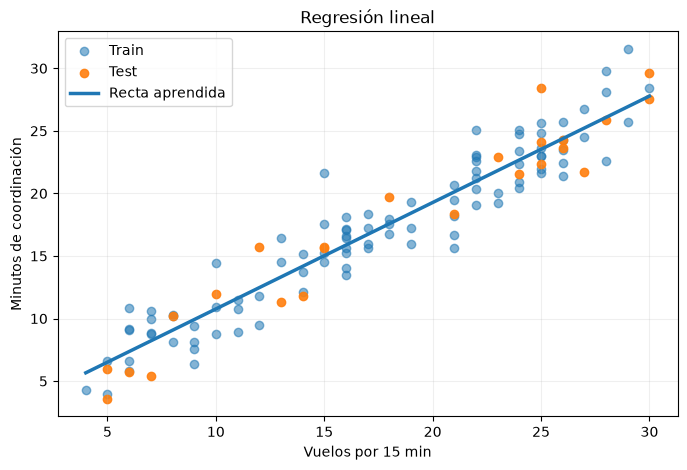

In [11]:
x_line = np.linspace(
    df["flights_15min"].min(),
    df["flights_15min"].max(),
    200
)

y_line = model.predict(
    pd.DataFrame({"flights_15min": x_line})
)

plt.figure(figsize=(8, 5))
plt.scatter(
    X_train["flights_15min"],
    y_train,
    alpha=0.55,
    label="Train"
)
plt.scatter(
    X_test["flights_15min"],
    y_test,
    alpha=0.9,
    label="Test"
)
plt.plot(
    x_line,
    y_line,
    linewidth=2.5,
    label="Recta aprendida"
)

plt.xlabel("Vuelos por 15 min")
plt.ylabel("Minutos de coordinación")
plt.title("Regresión lineal")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 9. Evaluar el modelo

Usaremos cuatro métricas:

### MAE

$$
MAE = \frac{1}{n}\sum |y_i-\hat{y_i}|
$$

Error absoluto medio. Está expresado en las mismas unidades que el target.

### MSE

$$
MSE = \frac{1}{n}\sum (y_i-\hat{y_i})^2
$$

Penaliza especialmente los errores grandes.

### RMSE

$$
RMSE = \sqrt{MSE}
$$

También está expresado en las unidades originales.

### $R^2$

Mide qué fracción de la variabilidad del target explica el modelo lineal.

- $R^2 = 1$: ajuste perfecto;
- $R^2 = 0$: no mejora, en términos de varianza explicada, frente a predecir la media;
- puede ser negativo en test si el modelo generaliza mal.

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.3f} min")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {rmse:.3f} min")
print(f"R²  : {r2:.3f}")


MAE : 1.605 min
MSE : 3.972
RMSE: 1.993 min
R²  : 0.934


## 10. Residuos

El residuo es:

\[
e_i = y_i - \hat{y_i}
\]

Si un modelo lineal es razonable, esperamos que los residuos estén aproximadamente repartidos alrededor de cero y que no aparezca una estructura clara.


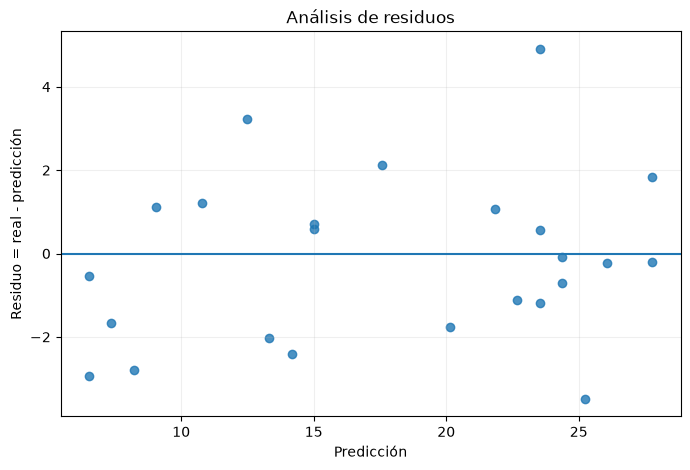

In [13]:
residuals = y_test.to_numpy() - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.8)
plt.axhline(0, linewidth=1.5)
plt.xlabel("Predicción")
plt.ylabel("Residuo = real - predicción")
plt.title("Análisis de residuos")
plt.grid(alpha=0.2)
plt.show()


Si viéramos una curva clara, forma de embudo u otro patrón sistemático, sería una señal de que una relación lineal simple quizá no está capturando correctamente el problema.


# 11. Qué está minimizando realmente el modelo

Podemos probar distintas pendientes manteniendo fijo un intercepto y calcular el MSE de cada una.

Esto nos permite visualizar la **función de pérdida**.


In [22]:
def mse_for_line(x, y, slope, intercept):
    predictions = intercept + slope * x
    return np.mean((y - predictions) ** 2)

x_train_np = X_train["flights_15min"].to_numpy()
y_train_np = y_train.to_numpy()

candidate_slopes = np.linspace(0.0, 1.7, 200)

losses = [
    mse_for_line(
        x_train_np,
        y_train_np,
        slope=slope,
        intercept=estimated_intercept
    )
    for slope in candidate_slopes
]

best_index = int(np.argmin(losses))

print("Pendiente con menor MSE en esta búsqueda:")
print(f"{candidate_slopes[best_index]:.3f}")


Pendiente con menor MSE en esta búsqueda:
0.854


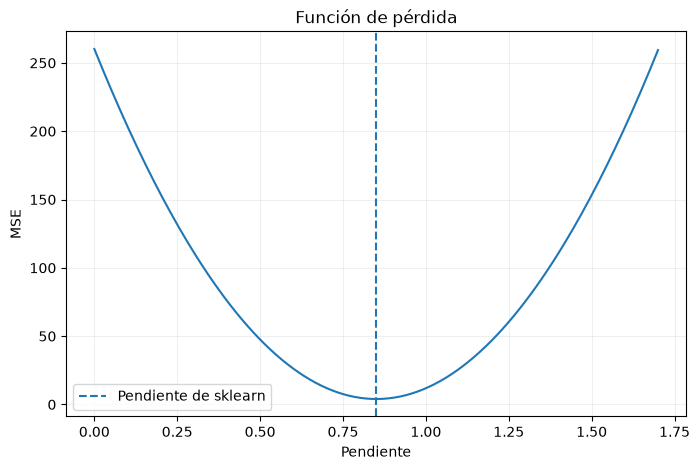

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(candidate_slopes, losses)
plt.axvline(estimated_slope, linestyle="--", label="Pendiente de sklearn")
plt.xlabel("Pendiente")
plt.ylabel("MSE")
plt.title("Función de pérdida")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


La regresión lineal busca los parámetros que minimizan el error cuadrático.

En este problema tan sencillo existe una solución matemática cerrada. Sin embargo, la idea de **ajustar parámetros minimizando una función de pérdida** es fundamental y volverá a aparecer continuamente en Machine Learning y Deep Learning.


# 12. Descenso de gradiente desde cero

Ahora implementaremos una versión muy sencilla del descenso de gradiente para aprender:

$$
\hat{y} = b + wx
$$

Queremos minimizar:

$$
MSE = \frac{1}{n}\sum (y_i-\hat{y_i})^2
$$

Los gradientes son:

$$
\frac{\partial MSE}{\partial w}
=
-\frac{2}{n}\sum x_i(y_i-\hat{y_i})
$$

$$
\frac{\partial MSE}{\partial b}
=
-\frac{2}{n}\sum (y_i-\hat{y_i})
$$


In [24]:
# Estandarizamos x solo para que el descenso de gradiente sea numéricamente cómodo.
x_mean = x_train_np.mean()
x_std = x_train_np.std()

x_scaled = (x_train_np - x_mean) / x_std

w = 0.0
b = y_train_np.mean()

learning_rate = 0.05
epochs = 200

loss_history = []

for epoch in range(epochs):
    y_hat = b + w * x_scaled

    errors = y_train_np - y_hat
    loss = np.mean(errors ** 2)
    loss_history.append(loss)

    dw = (-2 / len(x_scaled)) * np.sum(x_scaled * errors)
    db = (-2 / len(x_scaled)) * np.sum(errors)

    w -= learning_rate * dw
    b -= learning_rate * db

print(f"w escalado: {w:.3f}")
print(f"b escalado: {b:.3f}")
print(f"MSE final : {loss_history[-1]:.3f}")


w escalado: 6.057
b escalado: 17.075
MSE final : 3.972


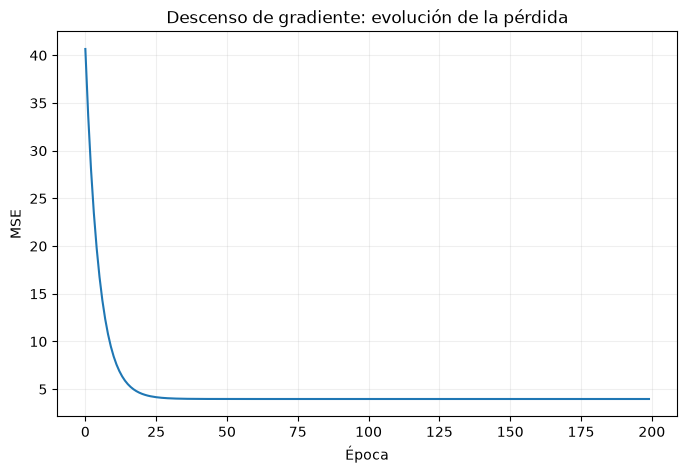

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Descenso de gradiente: evolución de la pérdida")
plt.grid(alpha=0.2)
plt.show()


Podemos transformar el modelo aprendido sobre `x_scaled` de nuevo a la escala original.

Como:

$$
x_{scaled} = \frac{x-\mu}{\sigma}
$$

entonces:

$$
b + w\frac{x-\mu}{\sigma}
=
\left(b-\frac{w\mu}{\sigma}\right)
+
\frac{w}{\sigma}x
$$


In [18]:
gd_slope = w / x_std
gd_intercept = b - (w * x_mean / x_std)

print(f"Descenso de gradiente -> intercepto: {gd_intercept:.3f}")
print(f"Descenso de gradiente -> pendiente : {gd_slope:.3f}")
print()
print(f"scikit-learn         -> intercepto: {estimated_intercept:.3f}")
print(f"scikit-learn         -> pendiente : {estimated_slope:.3f}")


Descenso de gradiente -> intercepto: 2.259
Descenso de gradiente -> pendiente : 0.851

scikit-learn         -> intercepto: 2.259
scikit-learn         -> pendiente : 0.851


Los resultados deberían ser muy parecidos.

La diferencia importante no es el algoritmo concreto usado internamente por `LinearRegression`, sino comprender la idea general:

```text
parámetros
    ↓
predicciones
    ↓
función de pérdida
    ↓
ajuste de parámetros
    ↓
mejores predicciones
```

Esta misma estructura conceptual aparecerá más adelante en redes neuronales.


# 13. Probar el modelo con un nuevo valor

Supongamos que queremos estimar el tiempo de coordinación para una ventana con 22 vuelos.


In [19]:
new_sample = pd.DataFrame({
    "flights_15min": [22]
})

prediction = model.predict(new_sample)[0]

print(f"Predicción para 22 vuelos: {prediction:.2f} minutos")


Predicción para 22 vuelos: 20.97 minutos


# 14. Ejercicios

Intenta responder o modificar el notebook antes de mirar soluciones externas.

### Ejercicio 1
¿Qué ocurre con MAE, RMSE y \(R^2\) si aumentas el ruido al generar los datos?

Prueba:

```python
noise = rng.normal(loc=0.0, scale=5.0, size=n_samples)
```

### Ejercicio 2
¿Qué ocurre si reducimos el conjunto de entrenamiento a muy pocas muestras?

### Ejercicio 3
Añade una predicción para 35 vuelos.

¿Es interpolación o extrapolación?

### Ejercicio 4
Cambia el `learning_rate` del descenso de gradiente:

```python
0.001
0.01
0.1
1.0
```

Observa qué ocurre con la función de pérdida.

### Ejercicio 5
Genera datos claramente no lineales, por ejemplo:

```python
coordination_minutes = 2 + 0.4 * flights_15min + 0.04 * flights_15min**2 + noise
```

y vuelve a entrenar una regresión lineal.

Mira especialmente el gráfico de residuos.


# 15. Ideas clave

Al terminar este notebook deberías poder explicar con tus propias palabras:

1. La diferencia entre `X` e `y`.
2. Qué representan pendiente e intercepto.
3. Qué significa hacer una predicción.
4. Qué es un residuo.
5. Por qué no evaluamos únicamente con los datos de entrenamiento.
6. Qué miden MAE, MSE, RMSE y \(R^2\).
7. Qué significa minimizar una función de pérdida.
8. Qué papel desempeña el *learning rate* en descenso de gradiente.
9. Por qué un buen ajuste estadístico no demuestra causalidad.
10. Por qué una relación lineal puede ser insuficiente para un problema real.

## Siguiente notebook

`02_logistic_regression.ipynb`

Pasaremos de predecir una magnitud continua a estimar la probabilidad de pertenecer a una clase.
